# Stochastic Foundations

Brownian motion, geometric Brownian motion, and Itô's lemma — the mathematical building blocks of quantitative finance.

**Theory references:** [Brownian Motion](../theory/01_stochastic/brownian_motion.md) | [Itô Calculus](../theory/01_stochastic/ito_calculus.md) | [SDEs](../theory/01_stochastic/sdes.md)

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.family': 'serif', 'font.size': 11, 'axes.labelsize': 11,
    'axes.titlesize': 12, 'axes.titleweight': 'normal',
    'legend.fontsize': 10, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
COLORS = ['#534AB7', '#0F6E56', '#D85A30', '#185FA5', '#993556', '#3B6D11', '#BA7517']

import os


def save_fig(fig, topic: str, name: str) -> None:
    """Save figure to ../plots/<topic>/ as both PDF and PNG."""
    folder = os.path.join('..', 'plots', topic)
    os.makedirs(folder, exist_ok=True)
    for ext in ('pdf', 'png'):
        fig.savefig(os.path.join(folder, f'{name}.{ext}'))

## Section 1 — Brownian Motion

### Definition

A **standard Brownian motion** (Wiener process) $\{W_t\}_{t \geq 0}$ is a continuous-time stochastic process satisfying four axioms:

1. **Initial condition:** $W_0 = 0$
2. **Independent increments:** for any $0 \leq t_1 < t_2 < \cdots < t_n$, the increments $W_{t_2} - W_{t_1},\, W_{t_3} - W_{t_2},\, \ldots,\, W_{t_n} - W_{t_{n-1}}$ are mutually independent
3. **Gaussian increments:** $W_t - W_s \sim \mathcal{N}(0,\, t - s)$ for all $0 \leq s < t$
4. **Continuous paths:** $t \mapsto W_t(\omega)$ is continuous almost surely

### Key Properties

From these axioms we derive the first two moments and the covariance structure:

$$\mathbb{E}[W_t] = 0, \qquad \mathrm{Var}(W_t) = t, \qquad \mathrm{Cov}(W_s, W_t) = \min(s, t)$$

The standard deviation of $W_t$ grows as $\sqrt{t}$, not $t$. This **square-root scaling** is fundamental: over $n$ independent time periods, uncertainty grows as $\sqrt{n}$, not $n$.

### Quadratic Variation

For a partition $\Pi = \{0 = t_0 < t_1 < \cdots < t_n = T\}$ with mesh size $|\Pi| \to 0$:

$$[W]_T \;=\; \lim_{|\Pi| \to 0} \sum_{i=0}^{n-1} (W_{t_{i+1}} - W_{t_i})^2 \;=\; T$$

Smooth functions have zero quadratic variation. Brownian motion's non-vanishing quadratic variation ($[W]_T = T$) generates the **Itô correction**: the extra $\tfrac{1}{2}\sigma^2 S^2 f''(S)$ term that distinguishes stochastic from ordinary calculus. In the Itô multiplication table this is the rule $dW \cdot dW = dt$.

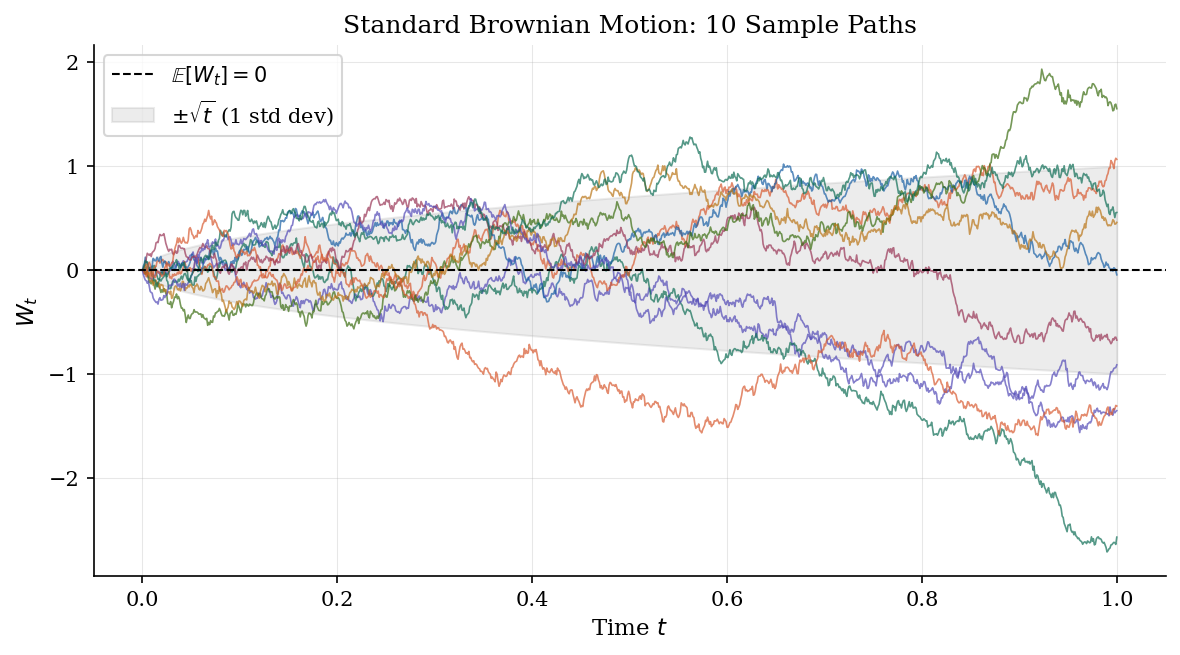

In [10]:
def simulate_bm(n_paths: int, n_steps: int, T: float,
                rng: np.random.Generator) -> tuple[np.ndarray, np.ndarray]:
    """Simulate standard Brownian motion paths.

    Parameters
    ----------
    n_paths : number of independent paths to simulate.
    n_steps : number of discrete time steps per path.
    T       : terminal time.
    rng     : NumPy random generator instance.

    Returns
    -------
    (time_grid, paths) where paths has shape (n_paths, n_steps+1).
    """
    dt = T / n_steps
    t = np.linspace(0, T, n_steps + 1)
    dW = rng.normal(0, np.sqrt(dt), size=(n_paths, n_steps))
    W = np.zeros((n_paths, n_steps + 1))
    W[:, 1:] = np.cumsum(dW, axis=1)
    return t, W


rng = np.random.default_rng(42)
t, paths = simulate_bm(n_paths=10, n_steps=1000, T=1.0, rng=rng)

fig, ax = plt.subplots(figsize=(8, 4.5))
for i in range(paths.shape[0]):
    ax.plot(t, paths[i], color=COLORS[i % len(COLORS)], alpha=0.7, linewidth=0.8)
ax.axhline(0, color='black', linewidth=1, linestyle='--',
           label=r'$\mathbb{E}[W_t] = 0$')
ax.fill_between(t, -np.sqrt(t), np.sqrt(t), alpha=0.15, color='grey',
                label=r'$\pm\sqrt{t}$ (1 std dev)')
ax.set_xlabel(r'Time $t$')
ax.set_ylabel(r'$W_t$')
ax.set_title('Standard Brownian Motion: 10 Sample Paths')
ax.legend(loc='upper left')
fig.tight_layout()
save_fig(fig, '01_stochastic', 'bm_sample_paths')
plt.show()

N =    10  |  QV = 0.849825  |  |QV - T| = 0.150175
N =    50  |  QV = 0.930085  |  |QV - T| = 0.069915
N =   100  |  QV = 0.842777  |  |QV - T| = 0.157223
N =   500  |  QV = 0.935177  |  |QV - T| = 0.064823
N =  1000  |  QV = 0.941072  |  |QV - T| = 0.058928
N =  5000  |  QV = 0.994565  |  |QV - T| = 0.005435
N = 10000  |  QV = 0.998172  |  |QV - T| = 0.001828


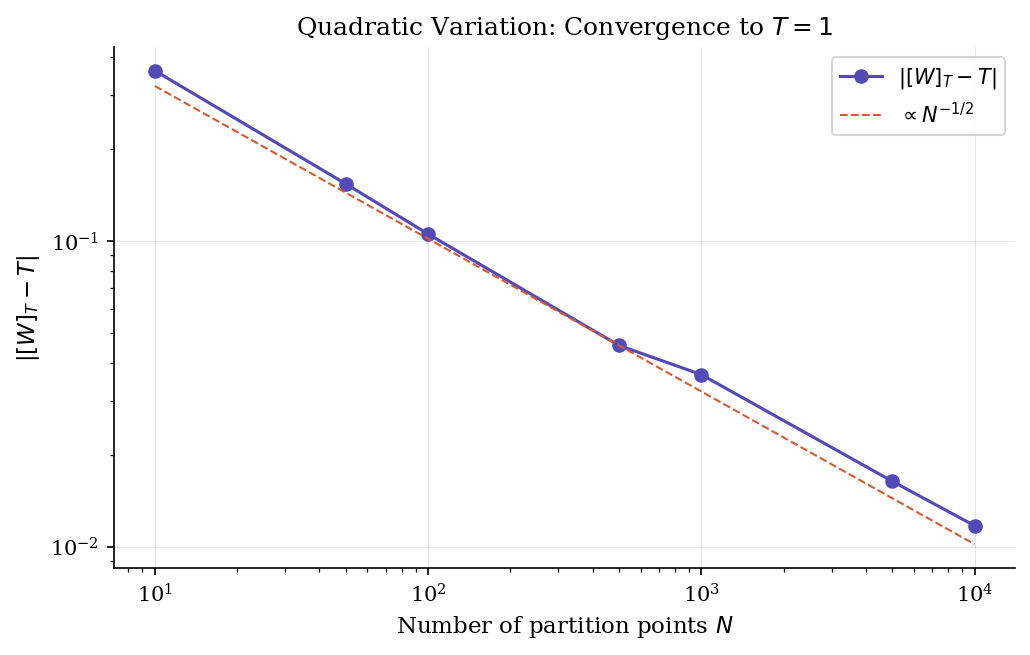

In [11]:
def compute_quadratic_variation(path: np.ndarray) -> float:
    """Compute quadratic variation of a discretized path: sum of squared increments."""
    return float(np.sum(np.diff(path) ** 2))


T = 1.0
N_fine = 100_000
rng_qv = np.random.default_rng(123)
_, W_fine = simulate_bm(n_paths=1, n_steps=N_fine, T=T, rng=rng_qv)
W_fine = W_fine[0]

N_values = [10, 50, 100, 500, 1000, 5000, 10000]
n_trials = 100
errors = []
for N in N_values:
    trial_errors = []
    for _ in range(n_trials):
        _, W = simulate_bm(n_paths=1, n_steps=N, T=T, rng=rng_qv)
        qv = compute_quadratic_variation(W[0])
        trial_errors.append(abs(qv - T))
    errors.append(np.mean(trial_errors))
    print(f'N = {N:>5d}  |  QV = {qv:.6f}  |  |QV - T| = {abs(qv - T):.6f}')

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(N_values, errors, 'o-', color=COLORS[0], linewidth=1.5,
          markersize=6, label=r'$|[W]_T - T|$')

N_arr = np.array(N_values, dtype=float)
c = errors[3] * N_values[3] ** 0.5
ax.loglog(N_values, c / N_arr ** 0.5, '--', color=COLORS[2], linewidth=1,
          label=r'$\propto N^{-1/2}$')

ax.set_xlabel(r'Number of partition points $N$')
ax.set_ylabel(r'$|[W]_T - T|$')
ax.set_title(r'Quadratic Variation: Convergence to $T = 1$')
ax.legend()
fig.tight_layout()
save_fig(fig, '01_stochastic', 'quadratic_variation_convergence')
plt.show()

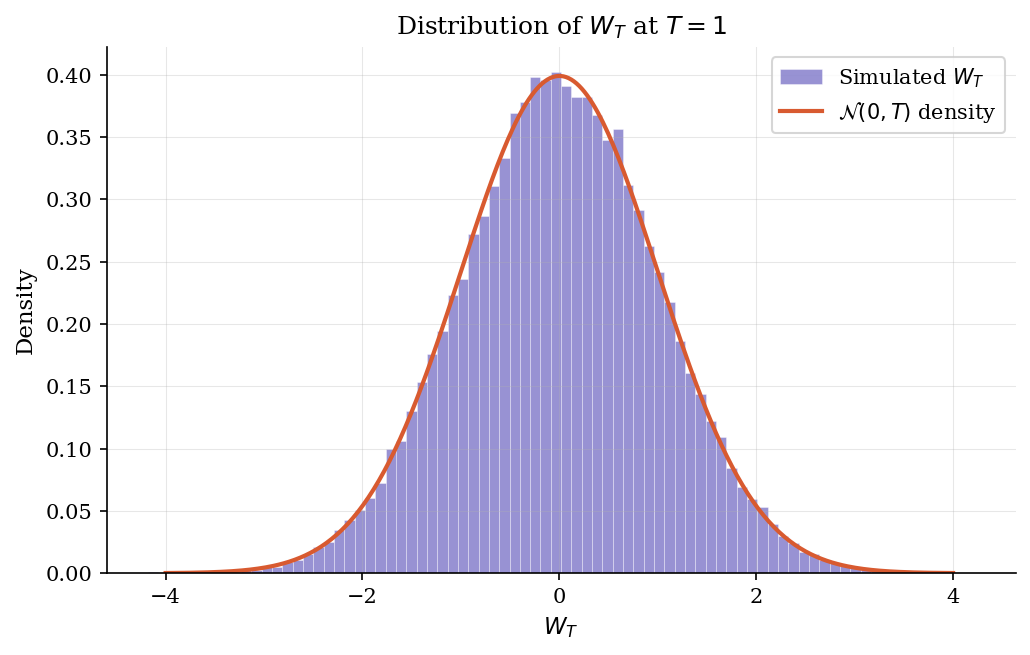

In [12]:
from scipy.stats import norm

rng_dist = np.random.default_rng(999)
_, W_dist = simulate_bm(n_paths=50_000, n_steps=100, T=1.0, rng=rng_dist)
W_T = W_dist[:, -1]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(W_T, bins=80, density=True, alpha=0.6, color=COLORS[0],
        edgecolor='white', linewidth=0.3, label=r'Simulated $W_T$')
x = np.linspace(-4, 4, 300)
ax.plot(x, norm.pdf(x, loc=0, scale=np.sqrt(1.0)), color=COLORS[2],
        linewidth=2, label=r'$\mathcal{N}(0, T)$ density')
ax.set_xlabel(r'$W_T$')
ax.set_ylabel('Density')
ax.set_title(r'Distribution of $W_T$ at $T = 1$')
ax.legend()
fig.tight_layout()
save_fig(fig, '01_stochastic', 'wt_distribution')
plt.show()

## Section 2 — Geometric Brownian Motion

### The SDE

Geometric Brownian Motion models a price process $S_t$ via the stochastic differential equation:

$$dS_t = \mu S_t \, dt + \sigma S_t \, dW_t$$

where $\mu$ is the drift (expected return) and $\sigma$ is the volatility.

### Exact Solution via Itô's Lemma

Applying Itô's lemma to $f(S) = \ln S$:

$$d(\ln S_t) = \left(\mu - \tfrac{1}{2}\sigma^2\right) dt + \sigma \, dW_t$$

Integrating from $0$ to $t$:

$$S_t = S_0 \exp\!\left[\left(\mu - \tfrac{1}{2}\sigma^2\right)t + \sigma W_t\right]$$

The $-\tfrac{1}{2}\sigma^2$ term is the **Itô correction** — it arises because $\exp$ is convex and Brownian motion has non-zero quadratic variation.

### Mean vs. Median: Jensen's Inequality

Since $S_t = S_0 \exp(X_t)$ where $X_t \sim \mathcal{N}\!\left((\mu - \sigma^2/2)t,\; \sigma^2 t\right)$:

$$\mathbb{E}[S_t] = S_0 e^{\mu t} \qquad \text{(mean — boosted by convexity of } \exp \text{)}$$

$$\text{Median}(S_t) = S_0 e^{(\mu - \sigma^2/2)t} \qquad \text{(typical path — the geometric average)}$$

The mean exceeds the median because $\exp$ is convex: by **Jensen's inequality**, $\mathbb{E}[e^X] > e^{\mathbb{E}[X]}$. A few explosive upward paths pull the mean above the typical (median) outcome. This gap grows with $\sigma^2$ — higher volatility amplifies the asymmetry.

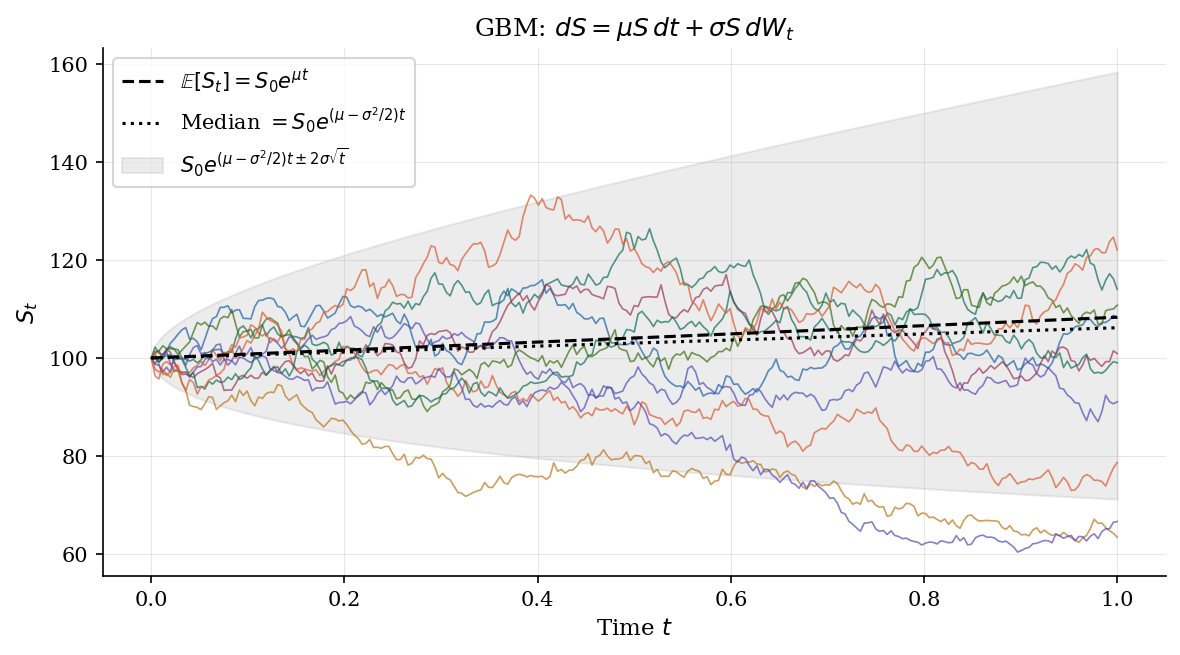

In [13]:
def simulate_gbm(S0: float, mu: float, sigma: float, T: float,
                 n_steps: int, n_paths: int,
                 rng: np.random.Generator) -> tuple[np.ndarray, np.ndarray]:
    """Simulate GBM paths using the exact (log-normal) solution.

    Uses S_t = S_0 * exp((mu - sigma^2/2)*t + sigma*W_t) rather than
    Euler-Maruyama, so there is no discretization error.

    Returns
    -------
    (time_grid, paths) where paths has shape (n_paths, n_steps+1).
    """
    t, W = simulate_bm(n_paths=n_paths, n_steps=n_steps, T=T, rng=rng)
    drift = (mu - 0.5 * sigma ** 2) * t[np.newaxis, :]
    S = S0 * np.exp(drift + sigma * W)
    return t, S


rng_gbm = np.random.default_rng(42)
S0, mu, sigma, T, n_steps = 100.0, 0.08, 0.2, 1.0, 252
t, S = simulate_gbm(S0, mu, sigma, T, n_steps, n_paths=10, rng=rng_gbm)

fig, ax = plt.subplots(figsize=(8, 4.5))
for i in range(S.shape[0]):
    ax.plot(t, S[i], color=COLORS[i % len(COLORS)], alpha=0.7, linewidth=0.8)
ax.plot(t, S0 * np.exp(mu * t), 'k--', linewidth=1.5,
        label=r'$\mathbb{E}[S_t] = S_0 e^{\mu t}$')
ax.plot(t, S0 * np.exp((mu - 0.5 * sigma ** 2) * t), 'k:', linewidth=1.5,
        label=r'Median $= S_0 e^{(\mu - \sigma^2/2)t}$')
upper = S0 * np.exp((mu - 0.5 * sigma**2) * t + 2 * sigma * np.sqrt(t))
lower = S0 * np.exp((mu - 0.5 * sigma**2) * t - 2 * sigma * np.sqrt(t))
ax.fill_between(t, lower, upper, alpha=0.15, color='grey',
                label=r'$S_0 e^{(\mu - \sigma^2/2)t \pm 2\sigma\sqrt{t}}$')
ax.set_xlabel(r'Time $t$')
ax.set_ylabel(r'$S_t$')
ax.set_title(r'GBM: $dS = \mu S\,dt + \sigma S\,dW_t$')
ax.legend(loc='upper left')
fig.tight_layout()
save_fig(fig, '01_stochastic', 'gbm_sample_paths')
plt.show()

In [14]:
import ipywidgets as widgets
from ipywidgets import interact


@interact(
    mu=widgets.FloatSlider(value=0.08, min=-0.2, max=0.5, step=0.01,
                           description=r'μ'),
    sigma=widgets.FloatSlider(value=0.2, min=0.05, max=0.8, step=0.01,
                              description=r'σ'),
)
def plot_gbm_interactive(mu: float = 0.08, sigma: float = 0.2) -> None:
    """Interactively plot GBM paths with adjustable drift and volatility."""
    rng_int = np.random.default_rng(42)
    S0_i, T_i, n_steps_i = 100.0, 1.0, 252
    t_i, S_i = simulate_gbm(S0_i, mu, sigma, T_i, n_steps_i,
                             n_paths=10, rng=rng_int)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for i in range(S_i.shape[0]):
        ax.plot(t_i, S_i[i], color=COLORS[i % len(COLORS)],
                alpha=0.7, linewidth=0.8)
    ax.plot(t_i, S0_i * np.exp(mu * t_i), 'k--', linewidth=1.5,
            label=r'$\mathbb{E}[S_t]$')
    ax.plot(t_i, S0_i * np.exp((mu - 0.5 * sigma ** 2) * t_i),
            'k:', linewidth=1.5, label='Median')
    ax.set_xlabel(r'Time $t$')
    ax.set_ylabel(r'$S_t$')
    ax.set_title(rf'GBM: $\mu$ = {mu:.2f}, $\sigma$ = {sigma:.2f}')
    ax.legend(loc='upper left')
    ax.set_ylim(0, max(300, S_i.max() * 1.1))
    fig.tight_layout()
    plt.show()

interactive(children=(FloatSlider(value=0.08, description='μ', max=0.5, min=-0.2, step=0.01), FloatSlider(valu…

## Section 3 — Itô's Lemma: Numerical Verification

### The Key Result

For GBM $dS = \mu S\,dt + \sigma S\,dW$, applying Itô's lemma to $f(S) = \ln S$ gives:

$$d(\ln S) = \left(\mu - \frac{\sigma^2}{2}\right)dt + \sigma\,dW$$

The $-\sigma^2/2$ drift correction is the central result of Itô calculus. It appears because $(\ln S)'' = -1/S^2$ and the quadratic variation of $S$ contributes a second-order term:

$$\tfrac{1}{2}\sigma^2 S^2 \cdot \left(-\frac{1}{S^2}\right) = -\tfrac{1}{2}\sigma^2$$

### Numerical Verification Strategy

1. **Single path:** simulate $dS = \mu S\,dt + \sigma S\,dW$ using Euler-Maruyama, compute $\ln S_T$ directly, and compare against the Itô formula $\ln S_0 + (\mu - \sigma^2/2)T + \sigma W_T$
2. **Monte Carlo:** run 10,000 Euler-Maruyama simulations, verify that $\ln(S_T/S_0) \sim \mathcal{N}\!\left((\mu - \sigma^2/2)T,\;\sigma^2 T\right)$

=== Single-path Itô verification ===
ln(S_T) from Euler-Maruyama : 4.352101
ln(S_T) from Itô formula    : 4.352674
Absolute error              : 5.72e-04

Theoretical: ln(S_T/S_0) ~ N(0.0550, 0.0900)


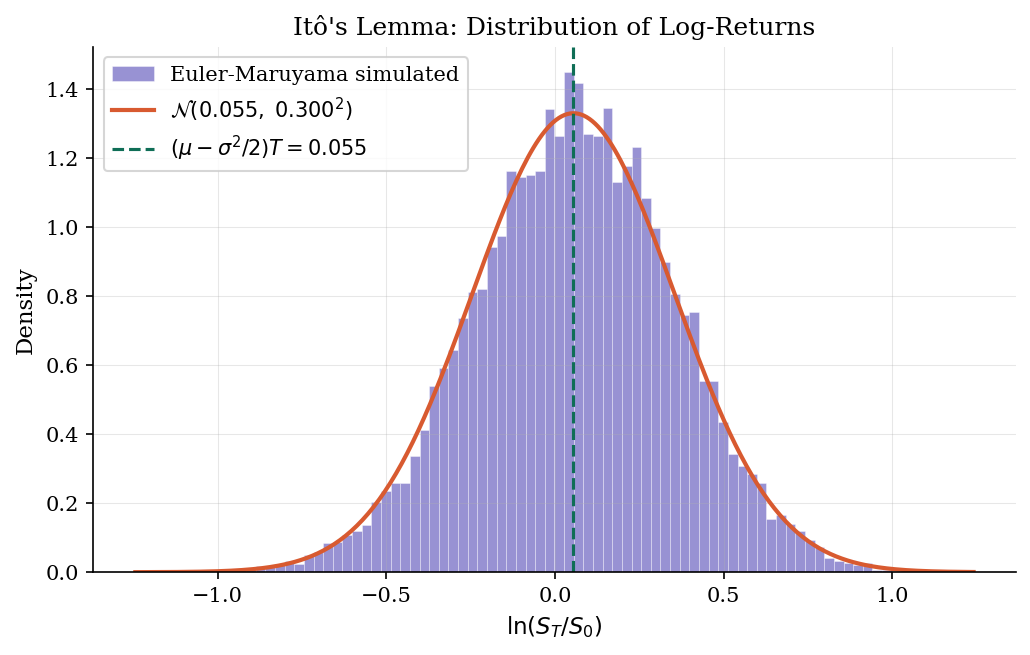

In [15]:
def euler_maruyama_gbm(S0: float, mu: float, sigma: float,
                       T: float, n_steps: int,
                       dW: np.ndarray) -> np.ndarray:
    """Simulate a single GBM path via Euler-Maruyama discretization.

    Parameters
    ----------
    dW : pre-generated Brownian increments of shape (n_steps,).

    Returns
    -------
    S : price path of shape (n_steps + 1,).
    """
    dt = T / n_steps
    S = np.zeros(n_steps + 1)
    S[0] = S0
    for i in range(n_steps):
        S[i + 1] = S[i] + mu * S[i] * dt + sigma * S[i] * dW[i]
    return S


# --- Part 1: Single-path verification ---
rng_ito = np.random.default_rng(42)
S0, mu, sigma, T, N = 100.0, 0.1, 0.3, 1.0, 10_000
dt = T / N
dW = rng_ito.normal(0, np.sqrt(dt), size=N)

S_em = euler_maruyama_gbm(S0, mu, sigma, T, N, dW)

ln_direct = np.log(S_em[-1])
ln_ito = np.log(S0) + (mu - 0.5 * sigma ** 2) * T + sigma * np.sum(dW)

print('=== Single-path Itô verification ===')
print(f'ln(S_T) from Euler-Maruyama : {ln_direct:.6f}')
print(f'ln(S_T) from Itô formula    : {ln_ito:.6f}')
print(f'Absolute error              : {abs(ln_direct - ln_ito):.2e}')
print(f'\nTheoretical: ln(S_T/S_0) ~ N({(mu - 0.5*sigma**2)*T:.4f}, {sigma**2*T:.4f})')

# --- Part 2: Monte Carlo histogram ---
from scipy.stats import norm

n_sims = 10_000
N_mc = 500
dt_mc = T / N_mc
rng_mc = np.random.default_rng(999)

S_mc = np.full(n_sims, S0)
for step in range(N_mc):
    dW_step = rng_mc.normal(0, np.sqrt(dt_mc), size=n_sims)
    S_mc = S_mc * (1.0 + mu * dt_mc + sigma * dW_step)

log_returns = np.log(S_mc / S0)
theo_mean = (mu - 0.5 * sigma ** 2) * T
theo_std = sigma * np.sqrt(T)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(log_returns, bins=80, density=True, alpha=0.6, color=COLORS[0],
        edgecolor='white', linewidth=0.3, label='Euler-Maruyama simulated')
x = np.linspace(log_returns.min() - 0.1, log_returns.max() + 0.1, 300)
theo_label = rf'$\mathcal{{N}}({theo_mean:.3f},\;{theo_std:.3f}^2)$'
ax.plot(x, norm.pdf(x, theo_mean, theo_std), color=COLORS[2], linewidth=2,
        label=theo_label)
ax.axvline(theo_mean, color=COLORS[1], linewidth=1.5, linestyle='--',
           label=rf'$(\mu - \sigma^2/2)T = {theo_mean:.3f}$')
ax.set_xlabel(r'$\ln(S_T / S_0)$')
ax.set_ylabel('Density')
ax.set_title("Itô's Lemma: Distribution of Log-Returns")
ax.legend()
fig.tight_layout()
save_fig(fig, '01_stochastic', 'ito_verification')
plt.show()

## Section 4 — Right Skew of GBM: Price Level Distribution

### Why Log-Returns Are Gaussian but Prices Are Not

The log-returns $\ln(S_T/S_0)$ are symmetric and Gaussian — but the price level $S_T = S_0 e^X$ is **lognormal** and right-skewed. The exponential transformation stretches the right tail: a $+2\sigma$ move in log-space produces a much larger price increase than a $-2\sigma$ move produces a decrease.

This directly causes the mean-median split:

$$\underbrace{\mathbb{E}[S_T] = S_0 e^{\mu T}}_{\text{pulled right by tail}} \quad > \quad \underbrace{\text{Median}(S_T) = S_0 e^{(\mu - \sigma^2/2)T}}_{\text{typical path}}$$

The gap is exactly the Itô correction $e^{-\sigma^2 T/2}$ — higher volatility means a fatter right tail, which pulls the mean further above the median.

#### The Economic Intuition: Why Capital "Works"

The mathematical structure of **Log-Normal distributions** explains why long-term investing is so powerful. While log-returns are symmetric, nominal prices behave asymmetrically:

* **Bounded Downside:** A price cannot fall below **0** (maximum -100% loss).
* **Unbounded Upside:** There is no mathematical ceiling to the right (**+500%, +1,000%, etc.**).



Due to this **right skew**, rare and extreme "outliers" pull the average (**Mean**) significantly above the typical outcome (**Median**). Capital "works" because time ($T$) and volatility ($\sigma$) stretch the distribution further to the right than it can ever fall to the left. By diversifying, investors harness this compounding structure where winners systematically overcompensate for capped losses.

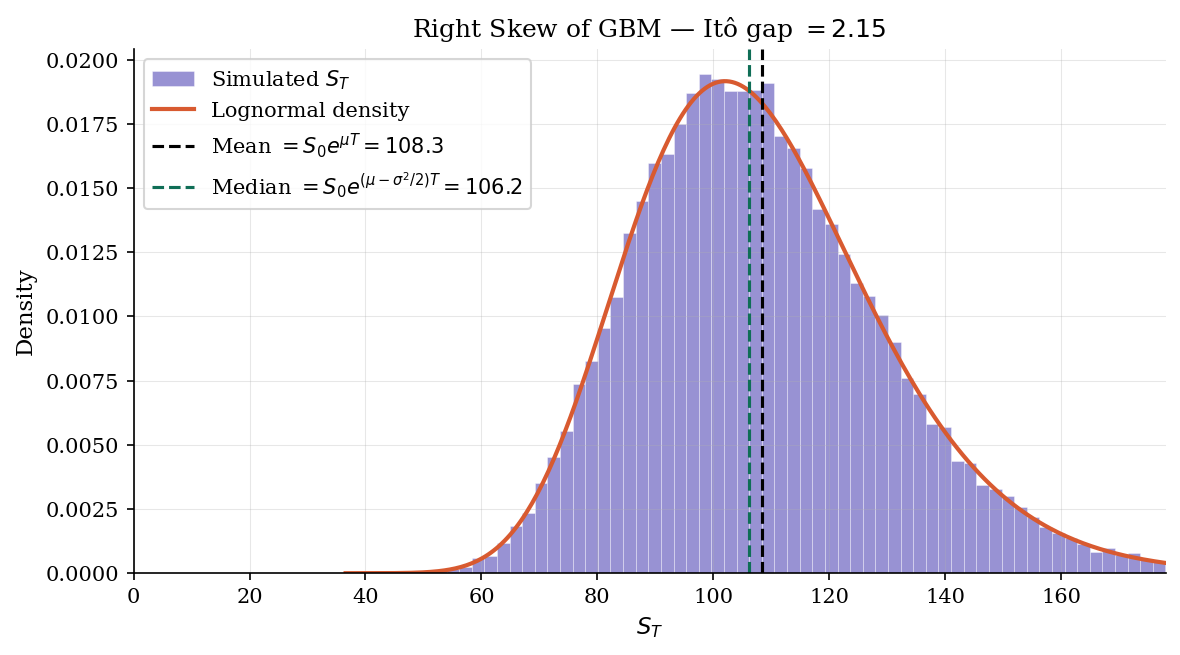

In [16]:
rng_skew = np.random.default_rng(42)
S0, mu, sigma, T = 100.0, 0.08, 0.2, 1.0
_, S_skew = simulate_gbm(S0, mu, sigma, T, n_steps=252,
                          n_paths=50_000, rng=rng_skew)
S_T = S_skew[:, -1]

mean_theory   = S0 * np.exp(mu * T)
median_theory = S0 * np.exp((mu - 0.5 * sigma**2) * T)

from scipy.stats import lognorm

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.linspace(S_T.min(), np.percentile(S_T, 99.5), 300)
scale = S0 * np.exp((mu - 0.5 * sigma**2) * T)
ax.hist(S_T, bins=100, density=True, alpha=0.6, color=COLORS[0],
        edgecolor='white', linewidth=0.3, label=r'Simulated $S_T$')
ax.plot(x, lognorm.pdf(x, s=sigma*np.sqrt(T), scale=scale),
        color=COLORS[2], linewidth=2, label='Lognormal density')
ax.axvline(mean_theory,   color='black',   linestyle='--', linewidth=1.5,
           label=rf'Mean $= S_0 e^{{\mu T}} = {mean_theory:.1f}$')
ax.axvline(median_theory, color=COLORS[1], linestyle='--', linewidth=1.5,
           label=rf'Median $= S_0 e^{{(\mu-\sigma^2/2)T}} = {median_theory:.1f}$')
ax.set_xlabel(r'$S_T$')
ax.set_ylabel('Density')
ax.set_title(rf'Right Skew of GBM — Itô gap $= {mean_theory - median_theory:.2f}$')
ax.set_xlim(0, np.percentile(S_T, 99.5))
ax.legend()
fig.tight_layout()
save_fig(fig, '01_stochastic', 'right_skew_gbm')
plt.show()

## Prosperity 4 Takeaways

- **Volatility scaling:** Price uncertainty grows as $\sigma\sqrt{t}$, not $\sigma t$ — over short Prosperity ticks, variance is tiny but non-zero, and the square-root scaling means $4\times$ more ticks only gives $2\times$ more uncertainty
- **The Itô correction matters:** When estimating drift from log-returns, the realized mean return is $(\mu - \sigma^2/2)$, not $\mu$ — failing to account for this leads to biased volatility estimates that directly affect spread calculations
- **Quadratic variation as a volatility estimator:** Sum of squared mid-price increments converges to realized variance — this is the fastest, model-free way to estimate $\sigma^2$ from Prosperity's tick data
- **GBM is a starting point, not the truth:** Real Prosperity prices have jumps, mean-reversion, and strategic behaviour — but GBM provides the baseline against which to measure deviations
- **Simulation is your lab:** Before deploying any strategy, simulate 10,000+ paths with calibrated parameters to stress-test inventory risk and PnL distributions